In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.preprocessing import StandardScaler

In [73]:
path = "../data/processed_data.csv"
df = pd.read_csv(path)
df = df.replace([np.inf, -np.inf], np.nan).dropna()
print(f"Shape: {df.shape}, NaNs: {df.isna().sum().sum()}")
df.head()

Shape: (1470, 37), NaNs: 0


,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,PerformanceIndex,...,YearsWithCurrManager,RemoteWork,MonthlyIncome,WelfareBenefits,InHouseFacility,ExternalFacility,ExtendedLeave,FlexibleWork,StressSelfReported,StressRating
0,0.448696,2.275186,0.590048,1.401512,-1.013529,-0.888082,-0.938496,-0.660531,-1.231716,1.383138,...,0.245533,-1.484408,-0.859256,-1.326566,-1.216109,-0.645124,-0.581016,-1.107823,-1.162892,4
1,1.323184,-0.439525,-0.913194,-0.493817,-0.152180,-1.863778,-0.938496,0.254625,0.811876,-0.240677,...,0.805990,0.142795,-0.029982,1.326566,0.822295,-0.645124,-0.581016,0.902671,-1.162892,2
2,0.011452,2.275186,0.590048,-0.493817,-0.890479,-0.888082,1.318192,1.169781,0.811876,1.284725,...,-1.155608,-0.670806,0.348985,-0.442189,0.822295,-0.645124,-0.581016,-1.107823,-1.162892,3
3,-0.425792,-0.439525,-0.913194,-0.493817,-0.767430,1.063309,-0.938496,1.169781,-1.231716,-0.486709,...,-1.155608,-0.670806,2.187149,1.326566,0.822295,1.550090,1.721123,0.902671,-1.162892,1
4,-1.081659,-0.439525,0.590048,-0.493817,-0.890479,-1.863778,0.565963,-1.575686,0.811876,-1.274014,...,-0.595151,-0.670806,-1.969845,-0.442189,-1.216109,-0.645124,-0.581016,-1.107823,0.943641,3


In [74]:
class LinearRegressionFromScratch:
    """
    Custom implementation of linear regression using gradient descent.
    """
    def __init__(self, learning_rate=0.0001, n_iterations=100000):
        self.coef_ = None
        self.intercept_ = None
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations

    def fit(self, X, y):
        """
        Fits the linear regression model to the given data using gradient descent.
        Args:
            X: A numpy array of shape (n_samples, n_features) representing the input data.
            y: A numpy array of shape (n_samples,) representing the target values.
        """
        m, n = X.shape
        self.coef_ = np.zeros((n, 1)) if y.ndim == 2 else np.zeros(n)
        self.intercept_ = 0.0

        for _ in range(self.n_iterations):
            # Calculate the predictions
            y_pred = self.predict(X)

            # Compute the residuals (raw difference, NOT squared)
            residual = y_pred - y

            # Calculate gradients for MSE loss
            intercept_gradient = (2/m) * np.sum(residual)
            coef_gradient = (2/m) * np.dot(X.T, residual)

            # Clip gradients to prevent overflow
            intercept_gradient = np.clip(intercept_gradient, -1e6, 1e6)
            coef_gradient = np.clip(coef_gradient, -1e6, 1e6)

            # Update the parameters using the gradients
            self.intercept_ -= self.learning_rate * intercept_gradient
            self.coef_ -= self.learning_rate * coef_gradient

            # Early stop if weights diverge
            if np.any(np.isnan(self.coef_)) or np.isnan(self.intercept_):
                print("Warning: NaN detected, stopping early. Try a smaller learning_rate.")
                break

    def predict(self, X):
        """
        Predicts the target values for new data.
        Args:
            X: A numpy array of shape (n_samples, n_features) representing the new input data.
        Returns:
            A numpy array of shape (n_samples,) representing the predicted target values.
        """
        return np.dot(X, self.coef_) + self.intercept_


class GradientBoostingRegressorFromScratch:
    """
    Custom implementation of Gradient Boosting Regressor using linear weak learners.
    Each weak learner is a simple linear model that learns residuals sequentially.
    """
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.random_state = random_state
        self.trees = []
        self.initial_prediction = None
        
    def fit(self, X, y):
        """
        Fits the gradient boosting model by sequentially learning residuals.
        Args:
            X: Feature matrix of shape (n_samples, n_features)
            y: Target values of shape (n_samples,)
        """
        np.random.seed(self.random_state)
        # Initial prediction is the mean of y
        self.initial_prediction = np.mean(y)
        predictions = np.full_like(y, self.initial_prediction, dtype=float).flatten()
        
        for i in range(self.n_estimators):
            # Calculate residuals (negative gradient for MSE loss)
            residuals = y.flatten() - predictions
            
            # Fit a simple linear model as weak learner to residuals
            weak_learner = LinearRegressionFromScratch(learning_rate=0.01, n_iterations=1000)
            weak_learner.fit(X, residuals.reshape(-1, 1))
            
            # Get weak learner predictions and flatten
            weak_pred = weak_learner.predict(X).flatten()
            
            # Update ensemble predictions with learning rate
            predictions += self.learning_rate * weak_pred
            self.trees.append(weak_learner)
    
    def predict(self, X):
        """
        Makes predictions using the ensemble of weak learners.
        Args:
            X: Feature matrix
        Returns:
            Predicted values of shape (n_samples,)
        """
        # Start with initial prediction
        predictions = np.full(X.shape[0], self.initial_prediction, dtype=float)
        
        # Add predictions from all weak learners
        for tree in self.trees:
            weak_pred = tree.predict(X).flatten()
            predictions += self.learning_rate * weak_pred
        
        return predictions

In [75]:
# Imports already included in first cell

In [76]:

target = 'StressRating'

# Find the best single feature by correlation
corrs = df.corr(numeric_only=True)[target].drop(target).abs().sort_values(ascending=False)
best_feature = corrs.index[0]
print(f"Best feature: {best_feature} (|corr| = {corrs.iloc[0]:.4f})")
print(f"Top 5:\n{corrs.head(5)}")

X = df.drop(columns=[target])
y = df[target].values.reshape(-1, 1)
print(f"\nX shape: {X.shape}, y shape: {y.shape}")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Best feature: WelfareBenefits (|corr| = 0.5882)
Top 5:
WelfareBenefits       0.588156
ExternalFacility      0.559452
InHouseFacility       0.552787
StressSelfReported    0.504541
FlexibleWork          0.453103
Name: StressRating, dtype: float64

X shape: (1470, 36), y shape: (1470, 1)


In [77]:

# === 1. Simple Linear Regression (Best Single Feature) ===
print(f"=== Simple Linear Regression: {best_feature} -> {target} ===\n")

X_train_simple = X_train[[best_feature]].values
X_test_simple = X_test[[best_feature]].values

# 1a. From Scratch Version
print("--- FROM SCRATCH VERSION ---")
model_simple_scratch = LinearRegressionFromScratch(learning_rate=0.001, n_iterations=100000)
model_simple_scratch.fit(X_train_simple, y_train)
y_pred_simple_scratch = model_simple_scratch.predict(X_test_simple)

mse_simple_scratch = mean_squared_error(y_test, y_pred_simple_scratch)
rmse_simple_scratch = np.sqrt(mse_simple_scratch)
r2_simple_scratch = r2_score(y_test, y_pred_simple_scratch)
print(f"MSE: {mse_simple_scratch:.4f} | RMSE: {rmse_simple_scratch:.4f} | R²: {r2_simple_scratch:.4f}")

# 1b. Library Version (sklearn)
print("\n--- LIBRARY VERSION (SKLEARN) ---")
model_simple_lib = LinearRegression()
model_simple_lib.fit(X_train_simple, y_train)
y_pred_simple_lib = model_simple_lib.predict(X_test_simple)

mse_simple_lib = mean_squared_error(y_test, y_pred_simple_lib)
rmse_simple_lib = np.sqrt(mse_simple_lib)
r2_simple_lib = r2_score(y_test, y_pred_simple_lib)
print(f"MSE: {mse_simple_lib:.4f} | RMSE: {rmse_simple_lib:.4f} | R²: {r2_simple_lib:.4f}")

# Store both for comparison
results_simple = {
    'From Scratch': {'mse': mse_simple_scratch, 'rmse': rmse_simple_scratch, 'r2': r2_simple_scratch, 'y_pred': y_pred_simple_scratch},
    'Sklearn': {'mse': mse_simple_lib, 'rmse': rmse_simple_lib, 'r2': r2_simple_lib, 'y_pred': y_pred_simple_lib}
}


=== Simple Linear Regression: WelfareBenefits -> StressRating ===

--- FROM SCRATCH VERSION ---
MSE: 0.5585 | RMSE: 0.7474 | R²: 0.3300

--- LIBRARY VERSION (SKLEARN) ---
MSE: 0.5585 | RMSE: 0.7474 | R²: 0.3300


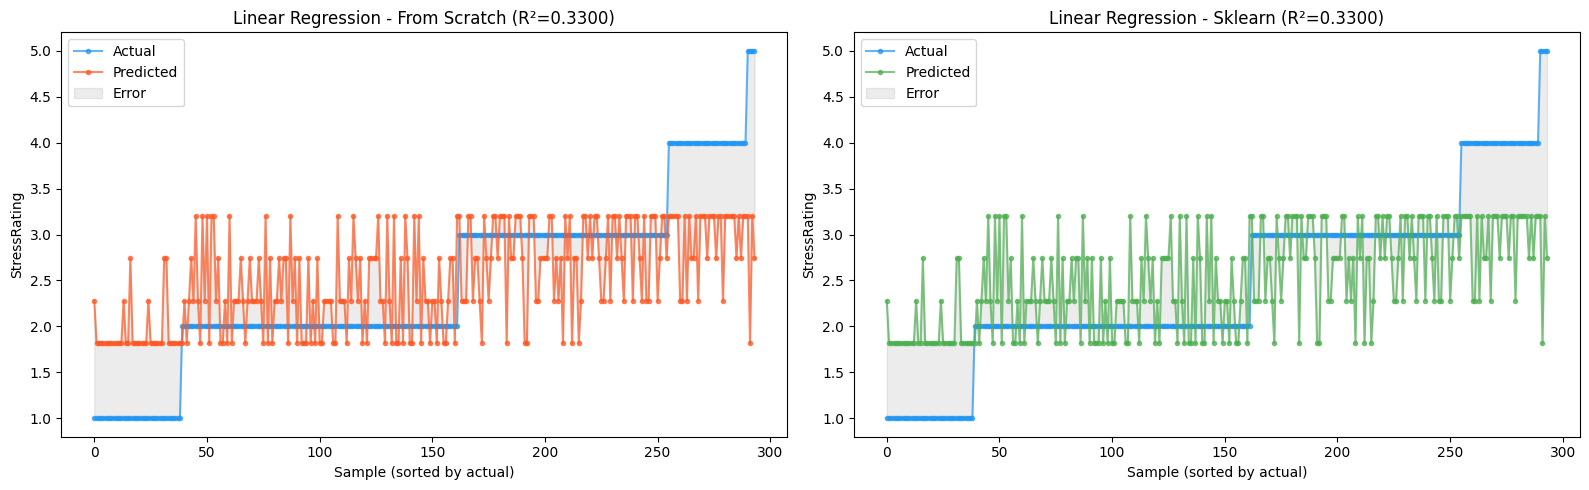

In [78]:

# Simple Linear Regression: Comparison Plots
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sort_idx = y_test.flatten().argsort()
y_actual_sorted = y_test.flatten()[sort_idx]

# From Scratch
y_pred_scratch_sorted = y_pred_simple_scratch.flatten()[sort_idx]
axes[0].plot(range(len(y_actual_sorted)), y_actual_sorted, 'o-', color='#2196F3', markersize=3, alpha=0.7, label='Actual')
axes[0].plot(range(len(y_pred_scratch_sorted)), y_pred_scratch_sorted, 'o-', color='#FF5722', markersize=3, alpha=0.7, label='Predicted')
axes[0].fill_between(range(len(y_actual_sorted)), y_actual_sorted, y_pred_scratch_sorted, alpha=0.15, color='gray', label='Error')
axes[0].set(xlabel="Sample (sorted by actual)", ylabel=target, title=f"Linear Regression - From Scratch (R²={r2_simple_scratch:.4f})")
axes[0].legend()

# Sklearn
y_pred_lib_sorted = y_pred_simple_lib.flatten()[sort_idx]
axes[1].plot(range(len(y_actual_sorted)), y_actual_sorted, 'o-', color='#2196F3', markersize=3, alpha=0.7, label='Actual')
axes[1].plot(range(len(y_pred_lib_sorted)), y_pred_lib_sorted, 'o-', color='#4CAF50', markersize=3, alpha=0.7, label='Predicted')
axes[1].fill_between(range(len(y_actual_sorted)), y_actual_sorted, y_pred_lib_sorted, alpha=0.15, color='gray', label='Error')
axes[1].set(xlabel="Sample (sorted by actual)", ylabel=target, title=f"Linear Regression - Sklearn (R²={r2_simple_lib:.4f})")
axes[1].legend()

plt.tight_layout()
plt.show()


In [79]:


# === 2. Multiple Regression with PCA (95% variance) ===
print(f"=== Multiple Regression with PCA -> {target} ===\n")

results_pca = {}
var_ratio = 0.95
pca = PCA(n_components=var_ratio)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

n_comp = pca.n_components_
print(f"PCA {int(var_ratio*100)}%: {n_comp} components (explains {pca.explained_variance_ratio_.sum():.4f})")

model_pca = LinearRegressionFromScratch(learning_rate=0.001, n_iterations=100000)
model_pca.fit(X_train_pca, y_train)
y_pred_pca = model_pca.predict(X_test_pca)

mse_pca = mean_squared_error(y_test, y_pred_pca)
r2_pca = r2_score(y_test, y_pred_pca)
print(f"MSE: {mse_pca:.4f} | RMSE: {np.sqrt(mse_pca):.4f} | R²: {r2_pca:.4f}\n")

results_pca[f"PCA {int(var_ratio*100)}%"] = {
    'n_components': n_comp, 'mse': mse_pca,
    'rmse': np.sqrt(mse_pca), 'r2': r2_pca, 'y_pred': y_pred_pca
}


=== Multiple Regression with PCA -> StressRating ===

PCA 95%: 29 components (explains 0.9564)
MSE: 0.3544 | RMSE: 0.5953 | R²: 0.5749



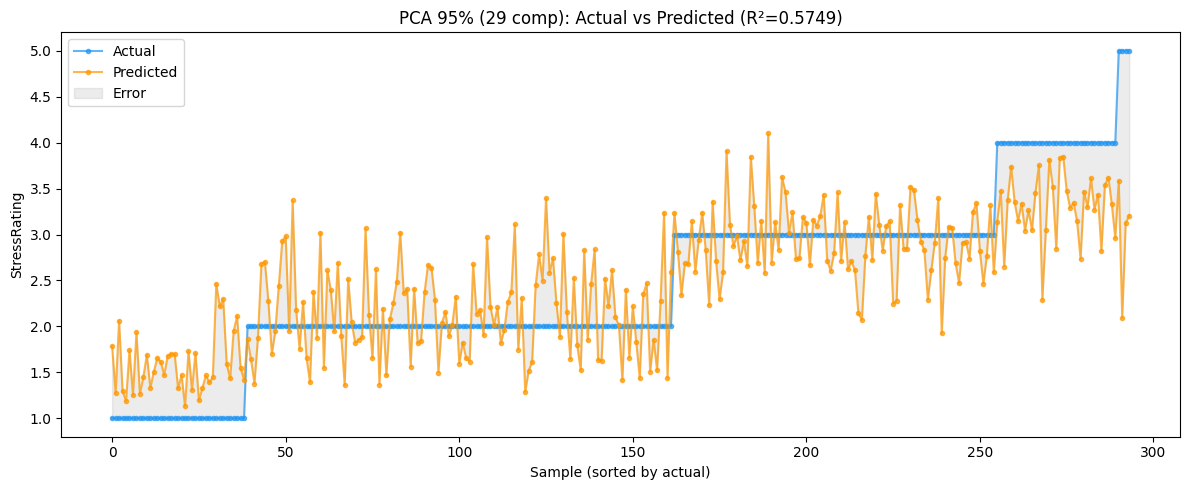

In [80]:

# Plot
fig, ax = plt.subplots(figsize=(12, 5))

sort_idx = y_test.flatten().argsort()
y_actual_sorted = y_test.flatten()[sort_idx]
y_pred_sorted = y_pred_pca.flatten()[sort_idx]

ax.plot(range(len(y_actual_sorted)), y_actual_sorted, 'o-', color='#2196F3', markersize=3, alpha=0.7, label='Actual')
ax.plot(range(len(y_pred_sorted)), y_pred_sorted, 'o-', color='#FF9800', markersize=3, alpha=0.7, label='Predicted')
ax.fill_between(range(len(y_actual_sorted)), y_actual_sorted, y_pred_sorted, alpha=0.15, color='gray', label='Error')
ax.set(xlabel="Sample (sorted by actual)", ylabel=target,
       title=f"PCA 95% ({n_comp} comp): Actual vs Predicted (R²={r2_pca:.4f})")
ax.legend()
plt.tight_layout()
plt.show()


In [81]:
# === 2b. Gradient Boosting Regression ===
# Gradient Boosting is a powerful ensemble method that builds trees sequentially to capture complex non-linear relationships.
print(f"=== Gradient Boosting Regression -> {target} ===\n")

y_train_gb = y_train.flatten()

# From Scratch Version
print("--- FROM SCRATCH VERSION ---")
model_gb_scratch = GradientBoostingRegressorFromScratch(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
model_gb_scratch.fit(X_train, y_train_gb)
y_pred_gb_scratch = model_gb_scratch.predict(X_test).reshape(-1, 1)

mse_gb_scratch = mean_squared_error(y_test, y_pred_gb_scratch)
rmse_gb_scratch = np.sqrt(mse_gb_scratch)
r2_gb_scratch = r2_score(y_test, y_pred_gb_scratch)
print(f"MSE: {mse_gb_scratch:.4f} | RMSE: {rmse_gb_scratch:.4f} | R²: {r2_gb_scratch:.4f}")

# Library Version (sklearn)
print("\n--- LIBRARY VERSION (SKLEARN) ---")
model_gb_lib = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
model_gb_lib.fit(X_train, y_train_gb)
y_pred_gb_lib = model_gb_lib.predict(X_test).reshape(-1, 1)

mse_gb_lib = mean_squared_error(y_test, y_pred_gb_lib)
rmse_gb_lib = np.sqrt(mse_gb_lib)
r2_gb_lib = r2_score(y_test, y_pred_gb_lib)
print(f"MSE: {mse_gb_lib:.4f} | RMSE: {rmse_gb_lib:.4f} | R²: {r2_gb_lib:.4f}")

results_gb = {
    'Gradient Boosting - From Scratch': {
        'n_features': X_train.shape[1], 'mse': mse_gb_scratch,
        'rmse': rmse_gb_scratch, 'r2': r2_gb_scratch, 'y_pred': y_pred_gb_scratch
    },
    'Gradient Boosting - Sklearn': {
        'n_features': X_train.shape[1], 'mse': mse_gb_lib,
        'rmse': rmse_gb_lib, 'r2': r2_gb_lib, 'y_pred': y_pred_gb_lib
    }
}

# === 2c. Gaussian Process Regression ===
# GP provides probabilistic predictions with uncertainty estimates.
print(f"\n=== Gaussian Process Regression -> {target} ===\n")

# Scale features for GP (recommended for better performance)
scaler_gp = StandardScaler()
X_train_gp = scaler_gp.fit_transform(X_train)
X_test_gp = scaler_gp.transform(X_test)

# Flatten y for GP (requires 1D)
y_train_gp = y_train.flatten()

# Define kernel: Constant * RBF
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))

# Train Gaussian Process
model_gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9, alpha=1e-6, random_state=42)
model_gp.fit(X_train_gp, y_train_gp)
y_pred_gp, y_std_gp = model_gp.predict(X_test_gp, return_std=True)
y_pred_gp = y_pred_gp.reshape(-1, 1)

mse_gp = mean_squared_error(y_test, y_pred_gp)
rmse_gp = np.sqrt(mse_gp)
r2_gp = r2_score(y_test, y_pred_gp)

print(f"Kernel: Constant * RBF")
print(f"MSE: {mse_gp:.4f} | RMSE: {rmse_gp:.4f} | R²: {r2_gp:.4f}")
print(f"Mean prediction std: {y_std_gp.mean():.4f}")

results_gp = {
    'Gaussian Process': {
        'n_features': X_train.shape[1], 'mse': mse_gp,
        'rmse': rmse_gp, 'r2': r2_gp, 'y_pred': y_pred_gp
    }
}

=== Gradient Boosting Regression -> StressRating ===

--- FROM SCRATCH VERSION ---
MSE: 0.3487 | RMSE: 0.5905 | R²: 0.5818

--- LIBRARY VERSION (SKLEARN) ---
MSE: 0.2986 | RMSE: 0.5465 | R²: 0.6418

=== Gaussian Process Regression -> StressRating ===

Kernel: Constant * RBF
MSE: 0.4539 | RMSE: 0.6737 | R²: 0.4555
Mean prediction std: 0.6081


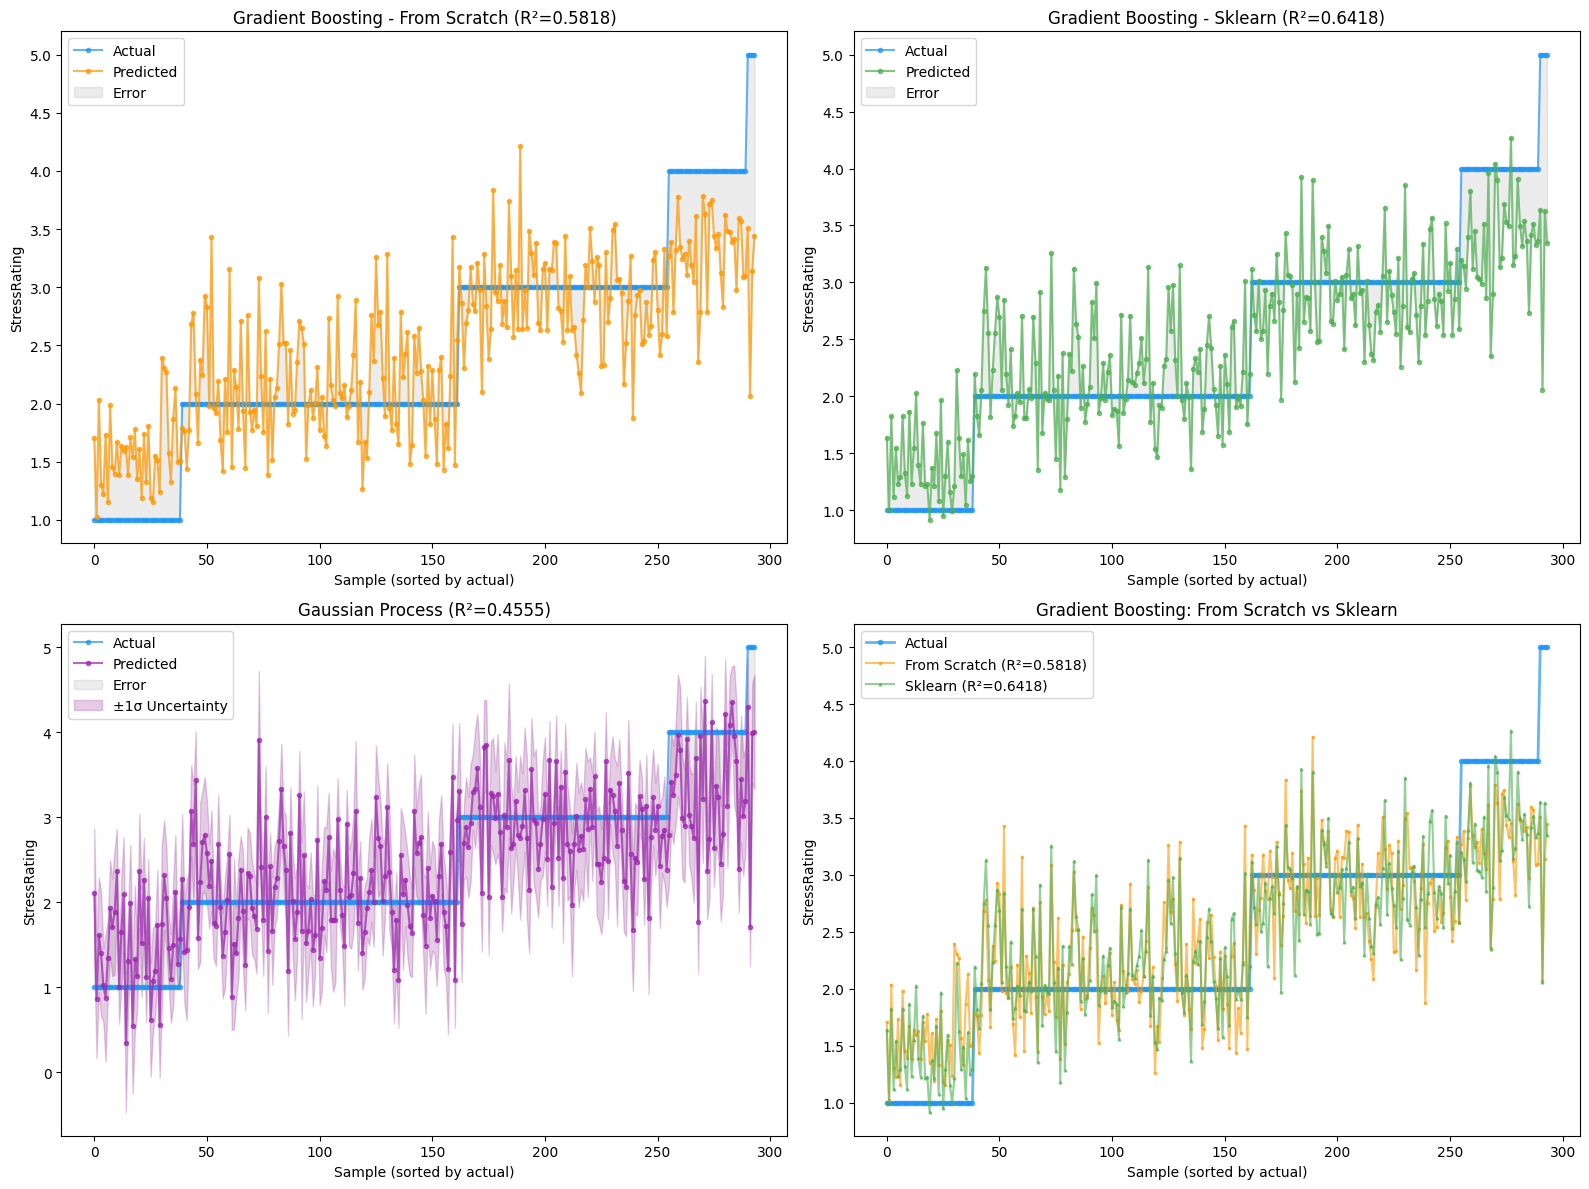

In [82]:
# Gradient Boosting and Gaussian Process Plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sort_idx = y_test.flatten().argsort()
y_actual_sorted = y_test.flatten()[sort_idx]

# Gradient Boosting - From Scratch (Top Left)
y_pred_gb_scratch_sorted = y_pred_gb_scratch.flatten()[sort_idx]
axes[0, 0].plot(range(len(y_actual_sorted)), y_actual_sorted, 'o-', color='#2196F3', markersize=3, alpha=0.7, label='Actual')
axes[0, 0].plot(range(len(y_pred_gb_scratch_sorted)), y_pred_gb_scratch_sorted, 'o-', color='#FF9800', markersize=3, alpha=0.7, label='Predicted')
axes[0, 0].fill_between(range(len(y_actual_sorted)), y_actual_sorted, y_pred_gb_scratch_sorted, alpha=0.15, color='gray', label='Error')
axes[0, 0].set(xlabel="Sample (sorted by actual)", ylabel=target,
               title=f"Gradient Boosting - From Scratch (R²={r2_gb_scratch:.4f})")
axes[0, 0].legend()

# Gradient Boosting - Sklearn (Top Right)
y_pred_gb_lib_sorted = y_pred_gb_lib.flatten()[sort_idx]
axes[0, 1].plot(range(len(y_actual_sorted)), y_actual_sorted, 'o-', color='#2196F3', markersize=3, alpha=0.7, label='Actual')
axes[0, 1].plot(range(len(y_pred_gb_lib_sorted)), y_pred_gb_lib_sorted, 'o-', color='#4CAF50', markersize=3, alpha=0.7, label='Predicted')
axes[0, 1].fill_between(range(len(y_actual_sorted)), y_actual_sorted, y_pred_gb_lib_sorted, alpha=0.15, color='gray', label='Error')
axes[0, 1].set(xlabel="Sample (sorted by actual)", ylabel=target,
               title=f"Gradient Boosting - Sklearn (R²={r2_gb_lib:.4f})")
axes[0, 1].legend()

# Gaussian Process (Bottom Left)
y_pred_gp_sorted = y_pred_gp.flatten()[sort_idx]
y_std_gp_sorted = y_std_gp[sort_idx]
axes[1, 0].plot(range(len(y_actual_sorted)), y_actual_sorted, 'o-', color='#2196F3', markersize=3, alpha=0.7, label='Actual')
axes[1, 0].plot(range(len(y_pred_gp_sorted)), y_pred_gp_sorted, 'o-', color='#9C27B0', markersize=3, alpha=0.7, label='Predicted')
axes[1, 0].fill_between(range(len(y_actual_sorted)), y_actual_sorted, y_pred_gp_sorted, alpha=0.15, color='gray', label='Error')
axes[1, 0].fill_between(range(len(y_actual_sorted)), 
                        y_pred_gp_sorted - y_std_gp_sorted,
                        y_pred_gp_sorted + y_std_gp_sorted, 
                        alpha=0.2, color='purple', label='±1σ Uncertainty')
axes[1, 0].set(xlabel="Sample (sorted by actual)", ylabel=target,
               title=f"Gaussian Process (R²={r2_gp:.4f})")
axes[1, 0].legend()

# Comparison: GB From Scratch vs Sklearn (Bottom Right)
axes[1, 1].plot(range(len(y_actual_sorted)), y_actual_sorted, 'o-', color='#2196F3', markersize=3, alpha=0.7, label='Actual', linewidth=2)
axes[1, 1].plot(range(len(y_pred_gb_scratch_sorted)), y_pred_gb_scratch_sorted, 's-', color='#FF9800', markersize=2, alpha=0.6, label=f'From Scratch (R²={r2_gb_scratch:.4f})')
axes[1, 1].plot(range(len(y_pred_gb_lib_sorted)), y_pred_gb_lib_sorted, '^-', color='#4CAF50', markersize=2, alpha=0.6, label=f'Sklearn (R²={r2_gb_lib:.4f})')
axes[1, 1].set(xlabel="Sample (sorted by actual)", ylabel=target,
               title="Gradient Boosting: From Scratch vs Sklearn")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [83]:
# === 3. Polynomial Regression (Degree 2, Top 15 Features) ===
top_features = corrs.head(15).index.tolist()
print(f"=== Polynomial Regression: {top_features} -> {target} ===\n")

X_train_poly_base = X_train[top_features].values
X_test_poly_base = X_test[top_features].values

degree = 2
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_train_poly = poly.fit_transform(X_train_poly_base)
X_test_poly = poly.transform(X_test_poly_base)

# 3a. From Scratch Version
print("--- FROM SCRATCH VERSION ---")
model_poly_scratch = LinearRegressionFromScratch(learning_rate=0.001, n_iterations=100000)
model_poly_scratch.fit(X_train_poly, y_train)
y_pred_poly_scratch = model_poly_scratch.predict(X_test_poly)

mse_poly_scratch = mean_squared_error(y_test, y_pred_poly_scratch)
rmse_poly_scratch = np.sqrt(mse_poly_scratch)
r2_poly_scratch = r2_score(y_test, y_pred_poly_scratch)
print(f"Degree {degree}: {X_train_poly.shape[1]} poly features")
print(f"MSE: {mse_poly_scratch:.4f} | RMSE: {rmse_poly_scratch:.4f} | R²: {r2_poly_scratch:.4f}")

# 3b. Library Version (sklearn)
print("\n--- LIBRARY VERSION (SKLEARN) ---")
model_poly_lib = LinearRegression()
model_poly_lib.fit(X_train_poly, y_train)
y_pred_poly_lib = model_poly_lib.predict(X_test_poly)

mse_poly_lib = mean_squared_error(y_test, y_pred_poly_lib)
rmse_poly_lib = np.sqrt(mse_poly_lib)
r2_poly_lib = r2_score(y_test, y_pred_poly_lib)
print(f"Degree {degree}: {X_train_poly.shape[1]} poly features")
print(f"MSE: {mse_poly_lib:.4f} | RMSE: {rmse_poly_lib:.4f} | R²: {r2_poly_lib:.4f}\n")

results_poly = {
    'Poly Deg 2 - From Scratch': {
        'mse': mse_poly_scratch, 'rmse': rmse_poly_scratch, 'r2': r2_poly_scratch,
        'y_pred': y_pred_poly_scratch
    },
    'Poly Deg 2 - Sklearn': {
        'mse': mse_poly_lib, 'rmse': rmse_poly_lib, 'r2': r2_poly_lib,
        'y_pred': y_pred_poly_lib
    }
}

=== Polynomial Regression: ['WelfareBenefits', 'ExternalFacility', 'InHouseFacility', 'StressSelfReported', 'FlexibleWork', 'ExtendedLeave', 'EnvironmentSatisfaction', 'WorkLifeBalance', 'Attrition', 'DistanceFromHome', 'JobSatisfaction', 'JobInvolvement', 'RelationshipSatisfaction', 'OverTime', 'MonthlyIncome'] -> StressRating ===

--- FROM SCRATCH VERSION ---
Degree 2: 135 poly features
MSE: 0.3496 | RMSE: 0.5913 | R²: 0.5806

--- LIBRARY VERSION (SKLEARN) ---
Degree 2: 135 poly features
MSE: 0.3497 | RMSE: 0.5914 | R²: 0.5805



COMPARISON: PCA 95% vs Polynomial Deg 2 (From Scratch vs Sklearn)

PCA 95% (From Scratch LR):
  Components: 29
  R² Score: 0.5749
  MSE: 0.3544

Polynomial Degree 2 - From Scratch:
  Features: 135 (15 base features)
  R² Score: 0.5806
  MSE: 0.3496

Polynomial Degree 2 - Sklearn:
  Features: 135 (15 base features)
  R² Score: 0.5805
  MSE: 0.3497

PERFORMANCE RANKING:
1. Poly Deg 2 (From Scratch): R² = 0.5806
2. Poly Deg 2 (Sklearn): R² = 0.5805
3. PCA 95% (From Scratch): R² = 0.5749


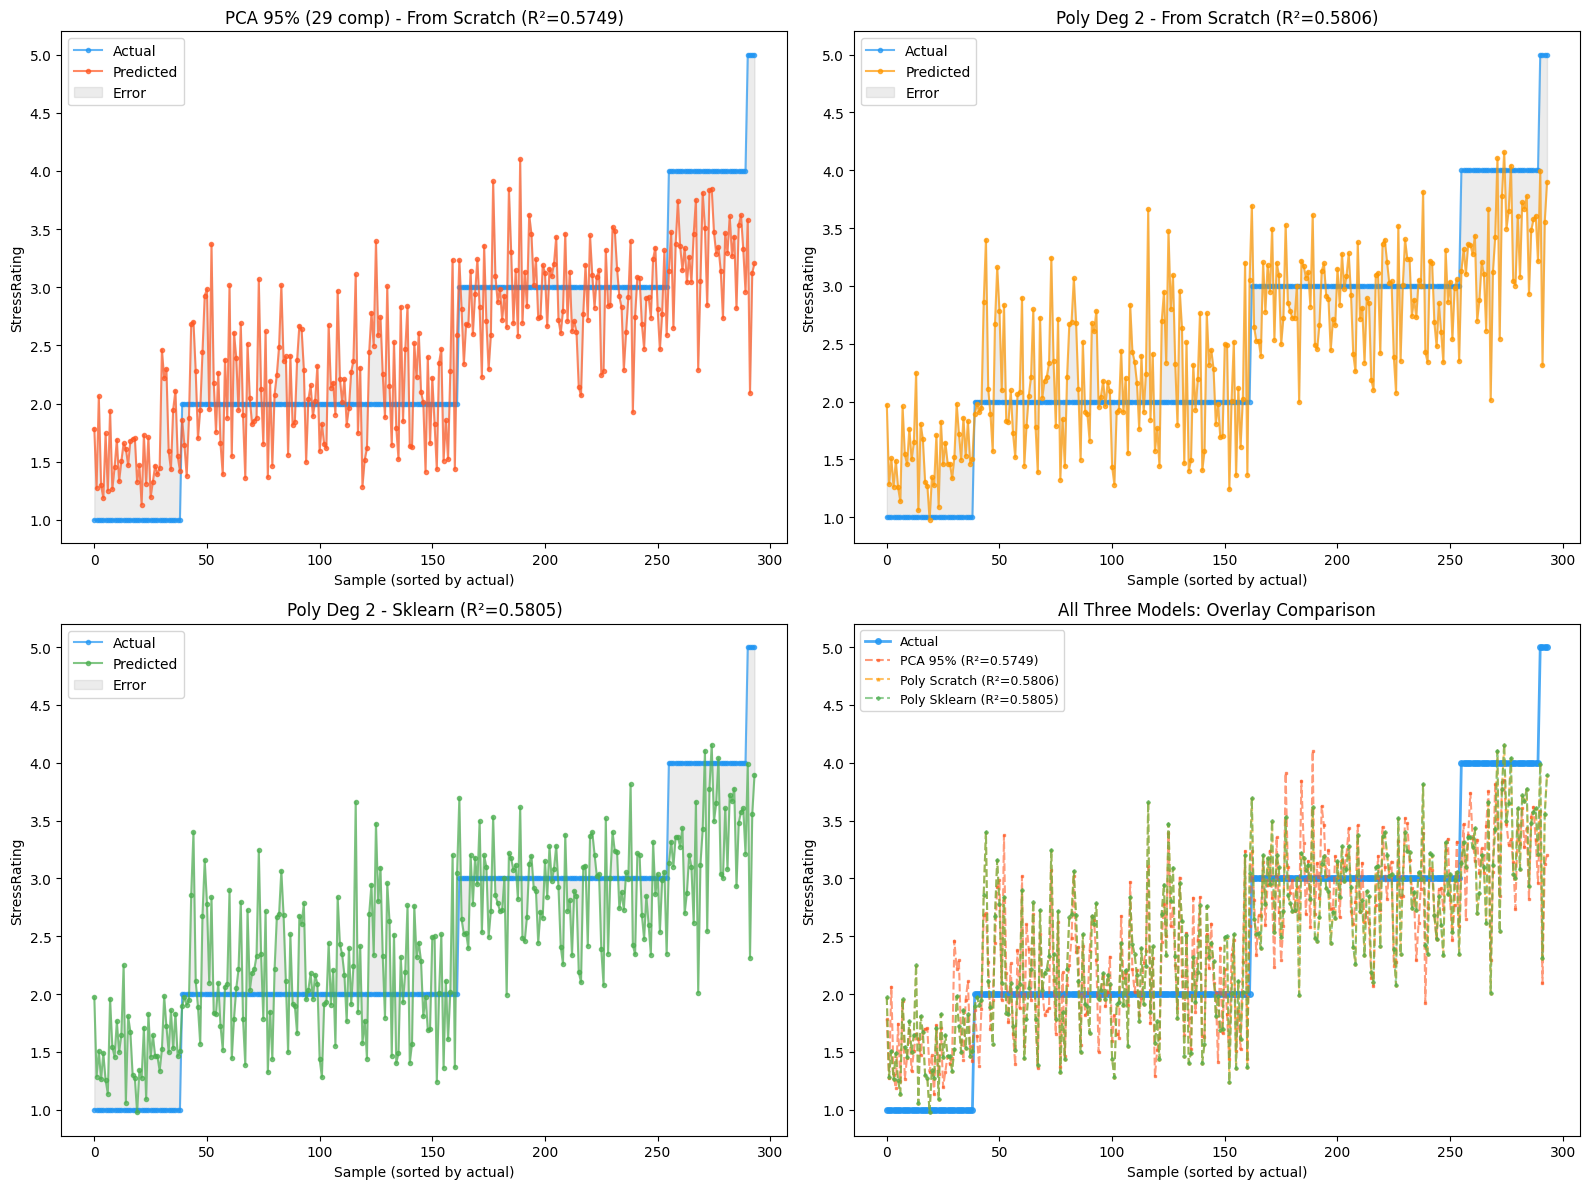

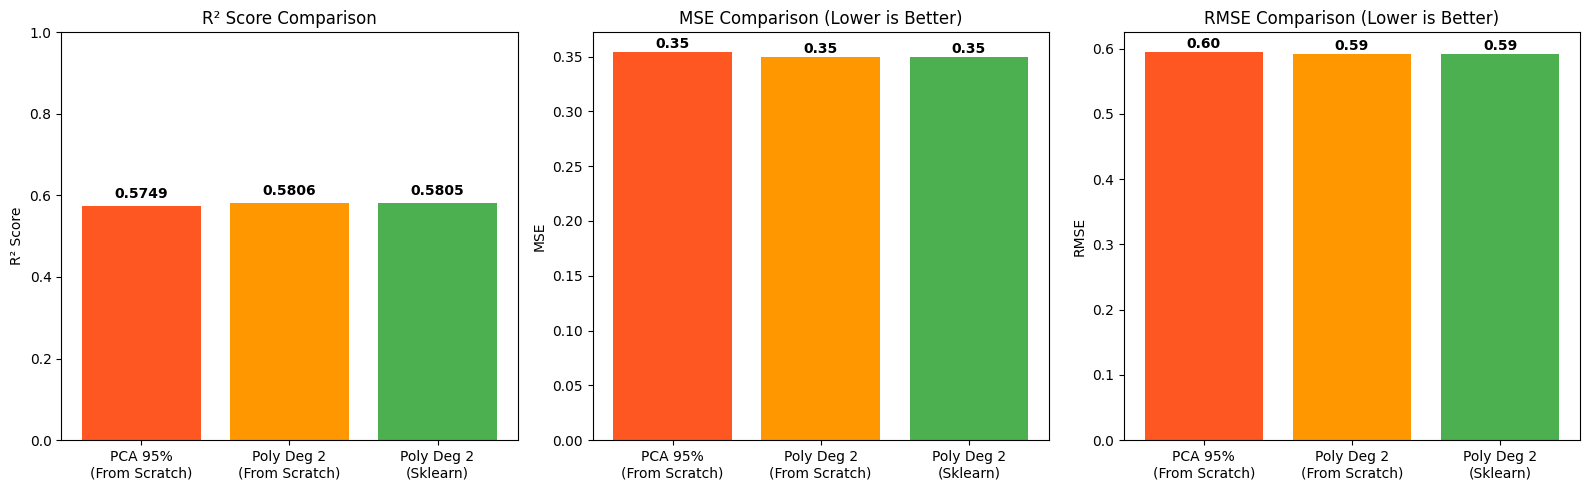

In [84]:
# === Comparison: PCA 95% vs Poly Deg 2 From Scratch vs Poly Deg 2 Sklearn ===
print("="*80)
print("COMPARISON: PCA 95% vs Polynomial Deg 2 (From Scratch vs Sklearn)")
print("="*80)

print("\nPCA 95% (From Scratch LR):")
print(f"  Components: {n_comp}")
print(f"  R² Score: {r2_pca:.4f}")
print(f"  MSE: {mse_pca:.4f}")

print("\nPolynomial Degree 2 - From Scratch:")
print(f"  Features: {X_train_poly.shape[1]} ({len(top_features)} base features)")
print(f"  R² Score: {r2_poly_scratch:.4f}")
print(f"  MSE: {mse_poly_scratch:.4f}")

print("\nPolynomial Degree 2 - Sklearn:")
print(f"  Features: {X_train_poly.shape[1]} ({len(top_features)} base features)")
print(f"  R² Score: {r2_poly_lib:.4f}")
print(f"  MSE: {mse_poly_lib:.4f}")

print("\n" + "="*80)
print("PERFORMANCE RANKING:")
print("="*80)
comparison_dict = {
    'PCA 95% (From Scratch)': r2_pca,
    'Poly Deg 2 (From Scratch)': r2_poly_scratch,
    'Poly Deg 2 (Sklearn)': r2_poly_lib
}
ranked = sorted(comparison_dict.items(), key=lambda x: x[1], reverse=True)
for i, (model, r2) in enumerate(ranked, 1):
    print(f"{i}. {model}: R² = {r2:.4f}")

# Comparison Plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sort_idx = y_test.flatten().argsort()
y_actual_sorted = y_test.flatten()[sort_idx]

# PCA 95% (Top Left)
y_pred_pca_sorted = y_pred_pca.flatten()[sort_idx]
axes[0, 0].plot(range(len(y_actual_sorted)), y_actual_sorted, 'o-', color='#2196F3', markersize=3, alpha=0.7, label='Actual')
axes[0, 0].plot(range(len(y_pred_pca_sorted)), y_pred_pca_sorted, 'o-', color='#FF5722', markersize=3, alpha=0.7, label='Predicted')
axes[0, 0].fill_between(range(len(y_actual_sorted)), y_actual_sorted, y_pred_pca_sorted, alpha=0.15, color='gray', label='Error')
axes[0, 0].set(xlabel="Sample (sorted by actual)", ylabel=target,
               title=f"PCA 95% ({n_comp} comp) - From Scratch (R²={r2_pca:.4f})")
axes[0, 0].legend()

# Poly Deg 2 - From Scratch (Top Right)
y_pred_poly_scratch_sorted = y_pred_poly_scratch.flatten()[sort_idx]
axes[0, 1].plot(range(len(y_actual_sorted)), y_actual_sorted, 'o-', color='#2196F3', markersize=3, alpha=0.7, label='Actual')
axes[0, 1].plot(range(len(y_pred_poly_scratch_sorted)), y_pred_poly_scratch_sorted, 'o-', color='#FF9800', markersize=3, alpha=0.7, label='Predicted')
axes[0, 1].fill_between(range(len(y_actual_sorted)), y_actual_sorted, y_pred_poly_scratch_sorted, alpha=0.15, color='gray', label='Error')
axes[0, 1].set(xlabel="Sample (sorted by actual)", ylabel=target,
               title=f"Poly Deg 2 - From Scratch (R²={r2_poly_scratch:.4f})")
axes[0, 1].legend()

# Poly Deg 2 - Sklearn (Bottom Left)
y_pred_poly_lib_sorted = y_pred_poly_lib.flatten()[sort_idx]
axes[1, 0].plot(range(len(y_actual_sorted)), y_actual_sorted, 'o-', color='#2196F3', markersize=3, alpha=0.7, label='Actual')
axes[1, 0].plot(range(len(y_pred_poly_lib_sorted)), y_pred_poly_lib_sorted, 'o-', color='#4CAF50', markersize=3, alpha=0.7, label='Predicted')
axes[1, 0].fill_between(range(len(y_actual_sorted)), y_actual_sorted, y_pred_poly_lib_sorted, alpha=0.15, color='gray', label='Error')
axes[1, 0].set(xlabel="Sample (sorted by actual)", ylabel=target,
               title=f"Poly Deg 2 - Sklearn (R²={r2_poly_lib:.4f})")
axes[1, 0].legend()

# Overlay Comparison (Bottom Right)
axes[1, 1].plot(range(len(y_actual_sorted)), y_actual_sorted, 'o-', color='#2196F3', markersize=4, alpha=0.8, label='Actual', linewidth=2)
axes[1, 1].plot(range(len(y_pred_pca_sorted)), y_pred_pca_sorted, 's--', color='#FF5722', markersize=2, alpha=0.6, label=f'PCA 95% (R²={r2_pca:.4f})')
axes[1, 1].plot(range(len(y_pred_poly_scratch_sorted)), y_pred_poly_scratch_sorted, '^--', color='#FF9800', markersize=2, alpha=0.6, label=f'Poly Scratch (R²={r2_poly_scratch:.4f})')
axes[1, 1].plot(range(len(y_pred_poly_lib_sorted)), y_pred_poly_lib_sorted, 'D--', color='#4CAF50', markersize=2, alpha=0.6, label=f'Poly Sklearn (R²={r2_poly_lib:.4f})')
axes[1, 1].set(xlabel="Sample (sorted by actual)", ylabel=target,
               title="All Three Models: Overlay Comparison")
axes[1, 1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Metric Comparison Bar Chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = ['PCA 95%\n(From Scratch)', 'Poly Deg 2\n(From Scratch)', 'Poly Deg 2\n(Sklearn)']
r2_scores = [r2_pca, r2_poly_scratch, r2_poly_lib]
mse_scores = [mse_pca, mse_poly_scratch, mse_poly_lib]
rmse_scores = [np.sqrt(mse_pca), rmse_poly_scratch, rmse_poly_lib]
colors = ['#FF5722', '#FF9800', '#4CAF50']

# R² Comparison
bars1 = axes[0].bar(models, r2_scores, color=colors)
axes[0].set_ylabel('R² Score')
axes[0].set_title('R² Score Comparison')
axes[0].set_ylim(0, 1.0)
for bar, val in zip(bars1, r2_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')

# MSE Comparison
bars2 = axes[1].bar(models, mse_scores, color=colors)
axes[1].set_ylabel('MSE')
axes[1].set_title('MSE Comparison (Lower is Better)')
for bar, val in zip(bars2, mse_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01*max(mse_scores),
                f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')

# RMSE Comparison
bars3 = axes[2].bar(models, rmse_scores, color=colors)
axes[2].set_ylabel('RMSE')
axes[2].set_title('RMSE Comparison (Lower is Better)')
for bar, val in zip(bars3, rmse_scores):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01*max(rmse_scores),
                f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


**Ridge Regression Strategy:**
- Uses **closed-form solution** $w = (X^TX + \alpha I)^{-1}X^Ty$ — runs instantly (no gradient descent)
- **Degree-2 polynomial features** on all columns for expressiveness
- **StandardScaler** ensures the L2 penalty treats all features equally
- **Alpha tuning** across 11 values to find optimal regularization strength

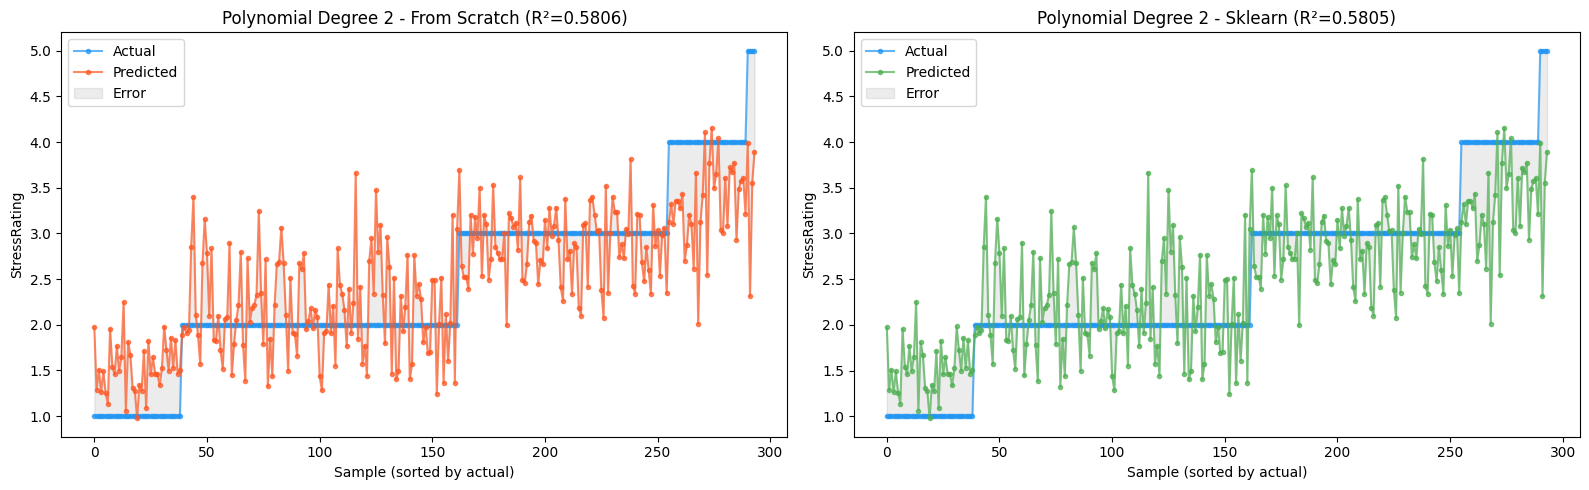

In [85]:

# Polynomial Regression: Comparison Plots
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sort_idx = y_test.flatten().argsort()
y_actual_sorted = y_test.flatten()[sort_idx]

# From Scratch
y_pred_poly_scratch_sorted = y_pred_poly_scratch.flatten()[sort_idx]
axes[0].plot(range(len(y_actual_sorted)), y_actual_sorted, 'o-', color='#2196F3', markersize=3, alpha=0.7, label='Actual')
axes[0].plot(range(len(y_pred_poly_scratch_sorted)), y_pred_poly_scratch_sorted, 'o-', color='#FF5722', markersize=3, alpha=0.7, label='Predicted')
axes[0].fill_between(range(len(y_actual_sorted)), y_actual_sorted, y_pred_poly_scratch_sorted, alpha=0.15, color='gray', label='Error')
axes[0].set(xlabel="Sample (sorted by actual)", ylabel=target, title=f"Polynomial Degree {degree} - From Scratch (R²={r2_poly_scratch:.4f})")
axes[0].legend()

# Sklearn
y_pred_poly_lib_sorted = y_pred_poly_lib.flatten()[sort_idx]
axes[1].plot(range(len(y_actual_sorted)), y_actual_sorted, 'o-', color='#2196F3', markersize=3, alpha=0.7, label='Actual')
axes[1].plot(range(len(y_pred_poly_lib_sorted)), y_pred_poly_lib_sorted, 'o-', color='#4CAF50', markersize=3, alpha=0.7, label='Predicted')
axes[1].fill_between(range(len(y_actual_sorted)), y_actual_sorted, y_pred_poly_lib_sorted, alpha=0.15, color='gray', label='Error')
axes[1].set(xlabel="Sample (sorted by actual)", ylabel=target, title=f"Polynomial Degree {degree} - Sklearn (R²={r2_poly_lib:.4f})")
axes[1].legend()

plt.tight_layout()
plt.show()


=== COMPLETE MODEL COMPARISON ===

                                     Model  Features      MSE     RMSE       R²
Simple LR (WelfareBenefits) - From Scratch         1 0.558536 0.747352 0.329999
     Simple LR (WelfareBenefits) - Sklearn         1 0.558536 0.747352 0.329999
                    PCA 95% (From Scratch)        29 0.354398 0.595313 0.574876
                 Poly Deg 2 - From Scratch       135 0.349631 0.591296 0.580594
                      Poly Deg 2 - Sklearn       135 0.349696 0.591351 0.580516
          Gradient Boosting - From Scratch        36 0.348654 0.590469 0.581766
               Gradient Boosting - Sklearn        36 0.298649 0.546488 0.641750
                          Gaussian Process        36 0.453888 0.673712 0.455530

Best model: Gradient Boosting - Sklearn (R² = 0.6418)


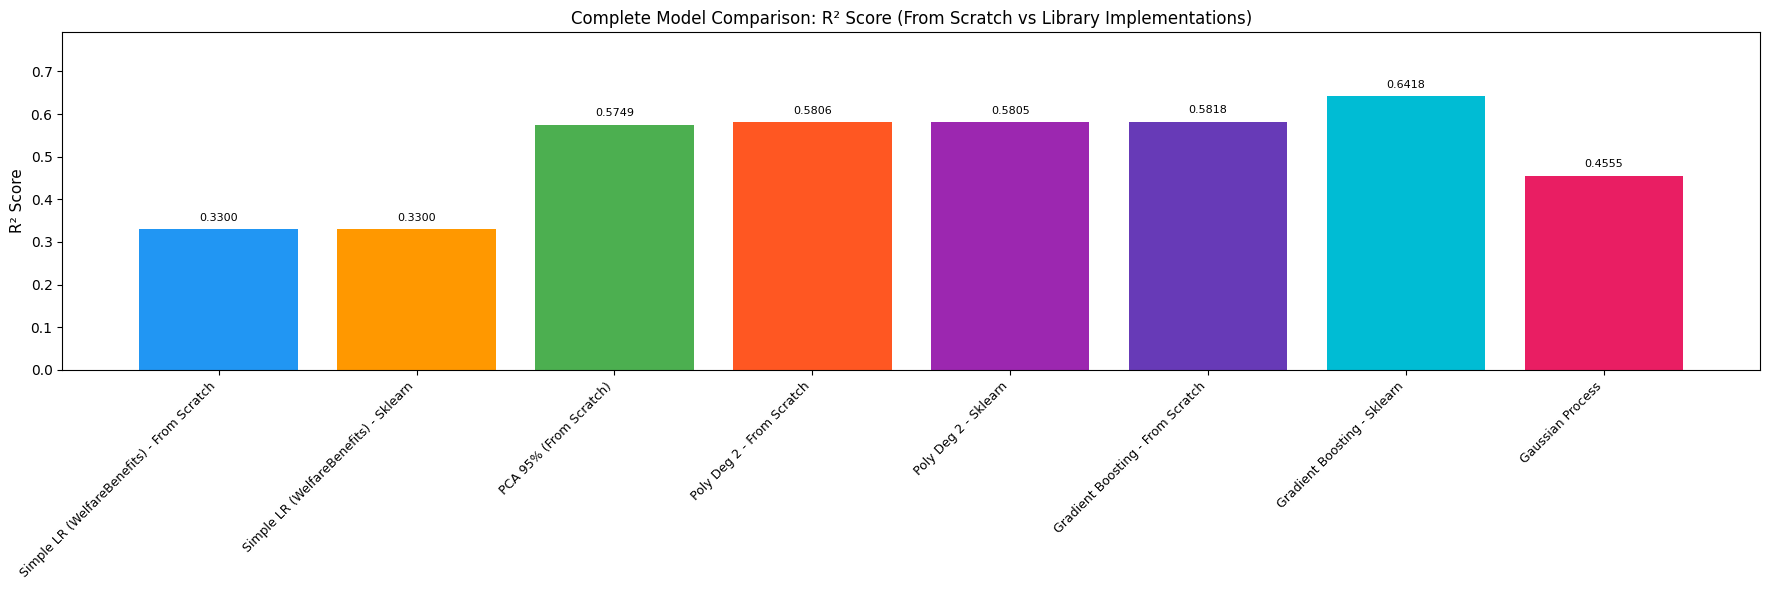



FROM SCRATCH vs LIBRARY IMPLEMENTATIONS - SUMMARY

LINEAR REGRESSION Comparison:
  From Scratch R²: 0.3300
  Sklearn R²:      0.3300
  Difference:      0.0000

POLYNOMIAL REGRESSION (Degree 2) Comparison:
  From Scratch R²: 0.5806
  Sklearn R²:      0.5805
  Difference:      0.0001

GRADIENT BOOSTING Comparison:
  From Scratch R²: 0.5818
  Sklearn R²:      0.6418
  Difference:      0.0600


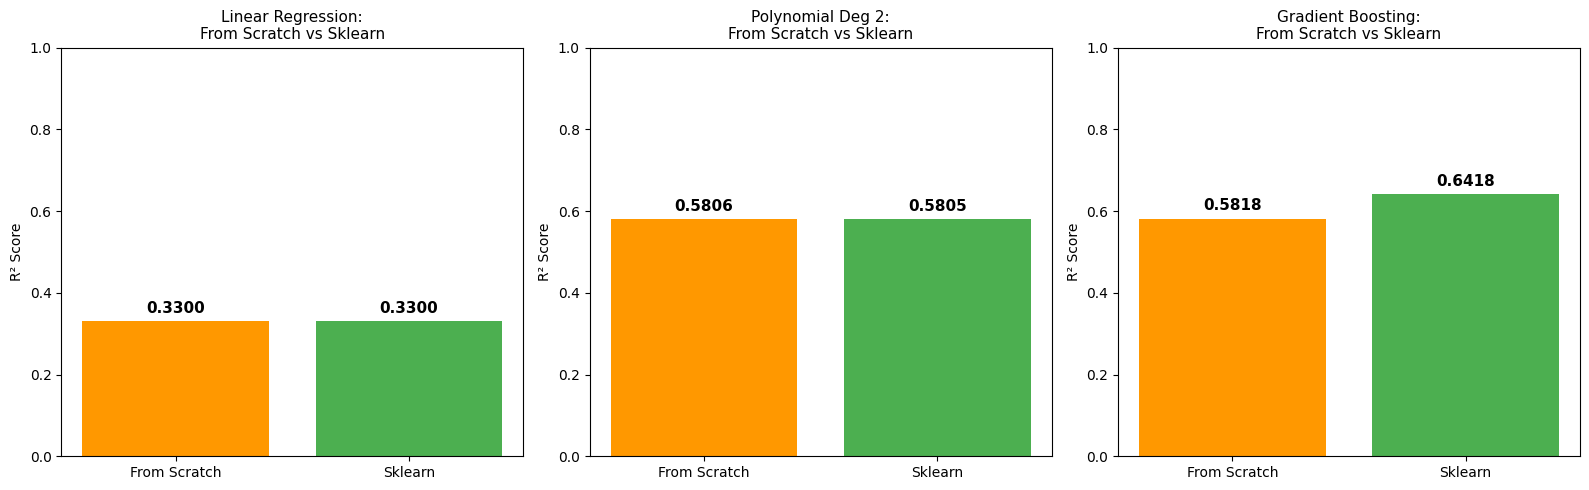

In [86]:
# === 4. Summary Comparison ===
summary_data = []

# Add Simple LR versions
for label, res in results_simple.items():
    summary_data.append({'Model': f'Simple LR ({best_feature}) - {label}', 'Features': 1,
                         'MSE': res['mse'], 'RMSE': res['rmse'], 'R²': res['r2']})

# Add PCA results (using from-scratch)
for label, res in results_pca.items():
    summary_data.append({'Model': f'{label} (From Scratch)', 'Features': res['n_components'],
                         'MSE': res['mse'], 'RMSE': res['rmse'], 'R²': res['r2']})

# Add Polynomial results (both)
for label, res in results_poly.items():
    summary_data.append({'Model': label, 'Features': X_train_poly.shape[1],
                         'MSE': res['mse'], 'RMSE': res['rmse'], 'R²': res['r2']})

# Add Gradient Boosting versions
for label, res in results_gb.items():
    summary_data.append({'Model': label, 'Features': res['n_features'],
                         'MSE': res['mse'], 'RMSE': res['rmse'], 'R²': res['r2']})

# Add Gaussian Process
for label, res in results_gp.items():
    summary_data.append({'Model': label, 'Features': res['n_features'],
                         'MSE': res['mse'], 'RMSE': res['rmse'], 'R²': res['r2']})

summary_df = pd.DataFrame(summary_data)
print("=== COMPLETE MODEL COMPARISON ===\n")
print(summary_df.to_string(index=False))

# Highlight best model
best_idx = summary_df['R²'].idxmax()
print(f"\nBest model: {summary_df.loc[best_idx, 'Model']} (R² = {summary_df.loc[best_idx, 'R²']:.4f})")

# R² bar chart
fig, ax = plt.subplots(figsize=(18, 6))
colors = ['#2196F3', '#FF9800', '#4CAF50', '#FF5722', '#9C27B0', '#673AB7', '#00BCD4', '#E91E63', '#009688', '#FFC107', '#795548']
bars = ax.bar(range(len(summary_df)), summary_df['R²'], color=colors[:len(summary_df)])
ax.set_xticks(range(len(summary_df)))
ax.set_xticklabels(summary_df['Model'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('R² Score', fontsize=11)
ax.set_title('Complete Model Comparison: R² Score (From Scratch vs Library Implementations)', fontsize=12)
ax.set_ylim(0, min(1.0, summary_df['R²'].max() + 0.15))
for i, (bar, val) in enumerate(zip(bars, summary_df['R²'])):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.4f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

# === 5. From Scratch vs Library Summaries ===
print("\n\n" + "="*80)
print("FROM SCRATCH vs LIBRARY IMPLEMENTATIONS - SUMMARY")
print("="*80)

print("\nLINEAR REGRESSION Comparison:")
print(f"  From Scratch R²: {r2_simple_scratch:.4f}")
print(f"  Sklearn R²:      {r2_simple_lib:.4f}")
print(f"  Difference:      {abs(r2_simple_lib - r2_simple_scratch):.4f}")

print("\nPOLYNOMIAL REGRESSION (Degree 2) Comparison:")
print(f"  From Scratch R²: {r2_poly_scratch:.4f}")
print(f"  Sklearn R²:      {r2_poly_lib:.4f}")
print(f"  Difference:      {abs(r2_poly_lib - r2_poly_scratch):.4f}")

print("\nGRADIENT BOOSTING Comparison:")
print(f"  From Scratch R²: {r2_gb_scratch:.4f}")
print(f"  Sklearn R²:      {r2_gb_lib:.4f}")
print(f"  Difference:      {abs(r2_gb_lib - r2_gb_scratch):.4f}")

# Comparison visualization - all from scratch vs library
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Linear Regression comparison
lr_models = ['From Scratch', 'Sklearn']
lr_r2 = [r2_simple_scratch, r2_simple_lib]
lr_colors = ['#FF9800', '#4CAF50']
bars1 = axes[0].bar(lr_models, lr_r2, color=lr_colors)
axes[0].set_ylabel('R² Score', fontsize=10)
axes[0].set_title('Linear Regression:\nFrom Scratch vs Sklearn', fontsize=11)
axes[0].set_ylim(0, 1.0)
for bar, val in zip(bars1, lr_r2):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')

# Polynomial Regression comparison
poly_models = ['From Scratch', 'Sklearn']
poly_r2 = [r2_poly_scratch, r2_poly_lib]
poly_colors = ['#FF9800', '#4CAF50']
bars2 = axes[1].bar(poly_models, poly_r2, color=poly_colors)
axes[1].set_ylabel('R² Score', fontsize=10)
axes[1].set_title('Polynomial Deg 2:\nFrom Scratch vs Sklearn', fontsize=11)
axes[1].set_ylim(0, 1.0)
for bar, val in zip(bars2, poly_r2):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')

# Gradient Boosting comparison
gb_models = ['From Scratch', 'Sklearn']
gb_r2 = [r2_gb_scratch, r2_gb_lib]
gb_colors = ['#FF9800', '#4CAF50']
bars3 = axes[2].bar(gb_models, gb_r2, color=gb_colors)
axes[2].set_ylabel('R² Score', fontsize=10)
axes[2].set_title('Gradient Boosting:\nFrom Scratch vs Sklearn', fontsize=11)
axes[2].set_ylim(0, 1.0)
for bar, val in zip(bars3, gb_r2):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()